# Phase 4 — Model B: 1D-CNN + Self Attention
## Blood Vessel Blockage Detection Project

**What is 1D-CNN?**
- CNN = Convolutional Neural Network
- Images ke liye 2D-CNN, tabular data ke liye **1D-CNN**
- CNN local patterns pakadta hai — jaise `PSV high + RI high + BFV low` ek saath

**What is Self-Attention?**
- Har feature ko puchho — 'Tum kitne important ho blockage mein?'
- Model khud seekhta hai kaunsa feature zyada dhyan dene wala hai
- Medical mein useful — RI aur PSV zyada important hain HR se

**Architecture:**
```
Input(15) → Reshape(15,1) → Conv1D(32,k=3) → Conv1D(64,k=3)
          → Self-Attention(64) → GlobalMaxPool → Dense(64) → Dense(1)
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, copy, warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
print('Libraries imported!')

Libraries imported!


---
## Step 1 — Load Phase 2 Labeled Data

In [2]:
df = pd.read_csv('phase2_labeled_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (2000, 19)


,peak_systolic_velocity,resistive_index,blood_flow_velocity,avg_temperature,temperature_difference,cold_spot_area_percent,heart_rate,pulse_amplitude,pulse_transit_time,hrv,velocity_ratio,thermal_stress,cardiac_load,vascular_resistance,flow_efficiency,blockage_score,blockage_label,confidence,risk_level
0,83.085284,0.696231,96.250183,36.574682,2.407925,6.796991,69.0,2.298226,0.196088,48.0,0.863222,16.366643,158.577612,0.136523,1.394930,0,0,High,Low Risk
1,129.254272,0.853361,64.919065,35.725150,3.708868,20.324207,113.0,0.840300,0.288642,24.0,1.991006,75.379801,94.953946,0.246316,0.574505,12,1,High,Critical Risk
2,105.756839,0.836293,64.084861,35.936101,4.405234,10.418063,86.0,1.151399,0.293710,56.0,1.650262,45.894002,99.020324,0.245627,0.745173,7,1,Medium,Critical Risk
3,133.971340,0.688480,69.625238,36.118859,3.347995,8.783595,94.0,1.752332,0.278041,50.0,1.924178,29.407435,164.719245,0.191426,0.740694,4,1,Low,High Risk
4,105.756839,0.696231,70.038666,36.995431,2.841834,5.616955,61.0,1.725171,0.212553,78.0,1.509978,15.962453,105.235446,0.147986,1.148175,0,0,High,Low Risk


In [3]:
feature_cols = [c for c in df.columns
                if c not in ['blockage_score','blockage_label','confidence','risk_level']]
X = df[feature_cols].values.astype(np.float64)
y = df['blockage_label'].values.astype(np.float64)
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (2000, 15)
y shape: (2000,)


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train,X_temp,y_train,y_temp = train_test_split(X_scaled,y,test_size=0.30,random_state=42,stratify=y)
X_val,X_test,y_val,y_test = train_test_split(X_temp,y_temp,test_size=0.50,random_state=42,stratify=y_temp)
print('Train:', X_train.shape, '| Val:', X_val.shape, '| Test:', X_test.shape)

Train: (1400, 15) | Val: (300, 15) | Test: (300, 15)


---
## Step 2 — Why Reshape to (batch, 15, 1)?

**1D-CNN features ko ek signal ki tarah treat karta hai:**
```
Features: [PSV, RI, BFV, Temp, TDiff, CSA, HR, PA, PTT, HRV, ...]
            ↑    ↑    ↑    ↑     ↑      ↑    ↑   ↑   ↑    ↑
           pos0 pos1 pos2 pos3  pos4   pos5 pos6 pos7 pos8 pos9

Filter(kernel=3) looks at 3 positions at a time:
[PSV, RI, BFV] → 'High PSV + High RI + Low BFV = Stenosis!'
```

In [5]:
# Reshape for CNN: (samples, features, 1)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_cnn   = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_cnn  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
print('CNN Input Shape:', X_train_cnn.shape)
print('Format: (patients, features, channels)')

CNN Input Shape: (1400, 15, 1)
Format: (patients, features, channels)


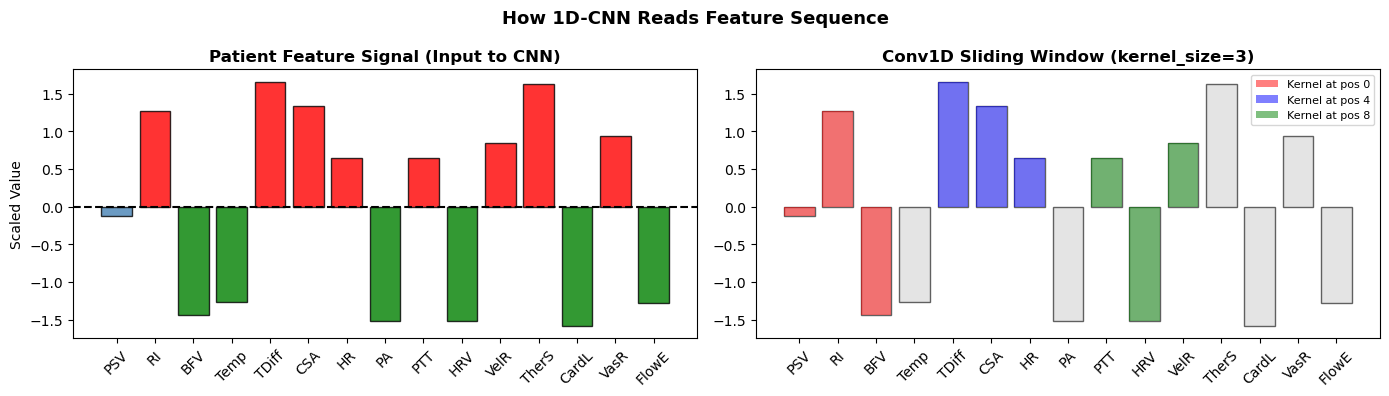

In [6]:
# Visualize feature signal
feature_abbrs = ['PSV','RI','BFV','Temp','TDiff','CSA','HR','PA','PTT','HRV',
                 'VelR','TherS','CardL','VasR','FlowE']
sample = X_train_cnn[0, :, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(feature_abbrs, sample,
            color=['red' if v > 0.5 else 'green' if v < -0.5 else 'steelblue' for v in sample],
            edgecolor='black', alpha=0.8)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Patient Feature Signal (Input to CNN)', fontweight='bold')
axes[0].set_ylabel('Scaled Value')
axes[0].tick_params(axis='x', rotation=45)

x_pos = np.arange(len(feature_abbrs))
axes[1].bar(x_pos, sample, color='lightgray', edgecolor='black', alpha=0.6)
for start, color in [(0,'red'),(4,'blue'),(8,'green')]:
    axes[1].bar(x_pos[start:start+3], sample[start:start+3],
                color=color, alpha=0.5, label=f'Kernel at pos {start}')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(feature_abbrs, rotation=45)
axes[1].set_title('Conv1D Sliding Window (kernel_size=3)', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('How 1D-CNN Reads Feature Sequence', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 3 — CNN + Self-Attention Architecture

**Self-Attention — Simple Explanation:**
```
Normal model:  PSV + RI + BFV + HR + HRV  (sab equal weight)

With Attention: PSV(0.28) + RI(0.25) + BFV(0.22) + HR(0.08) + HRV(0.07)
                ↑ important            ↑ important   ↑ less      ↑ less
```
**3 Steps:**
1. Query (Q) = Feature kya pooch raha hai
2. Key   (K) = Feature kya offer kar raha hai
3. Value (V) = Actual information
4. Score     = softmax(Q × K / sqrt(d)) × V

In [7]:
class Conv1D:
    """
    1D Convolution: Sliding window over feature sequence
    Input : (batch, length, in_channels)
    Output: (batch, length - kernel_size + 1, out_channels)
    """
    def __init__(self, in_ch, out_ch, kernel_size):
        self.k = kernel_size; self.oc = out_ch; self.ic = in_ch
        self.W = np.random.randn(kernel_size, in_ch, out_ch) * np.sqrt(2.0/(kernel_size*in_ch))
        self.b = np.zeros((1, 1, out_ch))
        self.mW=np.zeros_like(self.W); self.vW=np.zeros_like(self.W)
        self.mb=np.zeros_like(self.b); self.vb=np.zeros_like(self.b)

    def forward(self, X):
        B, L, _ = X.shape; self.X = X
        out_len = L - self.k + 1
        out = np.zeros((B, out_len, self.oc))
        for i in range(out_len):
            out[:, i, :] = np.einsum('bki,kio->bo', X[:, i:i+self.k, :], self.W) + self.b[0,0,:]
        self.out = out
        return out

    def backward(self, dout):
        B, L, _ = self.X.shape; out_len = L - self.k + 1
        self.dW = np.zeros_like(self.W)
        self.db = dout.sum(axis=(0,1), keepdims=True).reshape(1,1,-1)
        dX = np.zeros_like(self.X)
        for i in range(out_len):
            self.dW += np.einsum('bo,bki->kio', dout[:,i,:], self.X[:,i:i+self.k,:])
            dX[:, i:i+self.k, :] += np.einsum('bo,kio->bki', dout[:,i,:], self.W)
        return dX


class SelfAttention:
    """
    Self-Attention: Features weight each other
    Input/Output: (batch, seq_len, d_model)
    """
    def __init__(self, d_model):
        self.d = d_model
        s = np.sqrt(2.0/d_model)
        self.Wq = np.random.randn(d_model, d_model)*s
        self.Wk = np.random.randn(d_model, d_model)*s
        self.Wv = np.random.randn(d_model, d_model)*s
        self.Wo = np.random.randn(d_model, d_model)*s
        for nm in ['Wq','Wk','Wv','Wo']:
            setattr(self,f'm{nm}',np.zeros((d_model,d_model)))
            setattr(self,f'v{nm}',np.zeros((d_model,d_model)))

    def softmax(self, x):
        e = np.exp(x - x.max(axis=-1, keepdims=True))
        return e / e.sum(axis=-1, keepdims=True)

    def forward(self, X):
        self.X = X
        self.Q = X @ self.Wq; self.K = X @ self.Wk; self.V = X @ self.Wv
        scores = self.Q @ self.K.transpose(0,2,1) / np.sqrt(self.d)
        self.A = self.softmax(scores)          # attention weights
        ctx    = self.A @ self.V
        self.out = ctx @ self.Wo + X          # + residual connection
        return self.out

    def backward(self, dout):
        self.dWo = (self.A @ self.V).reshape(-1,self.d).T @ dout.reshape(-1,self.d)
        dctx  = dout @ self.Wo.T
        dV    = self.A.transpose(0,2,1) @ dctx
        dA    = dctx @ self.V.transpose(0,2,1)
        ds    = self.A*(dA-(dA*self.A).sum(axis=-1,keepdims=True))/np.sqrt(self.d)
        dQ=ds@self.K; dK=ds.transpose(0,2,1)@self.Q
        self.dWq=self.X.reshape(-1,self.d).T@dQ.reshape(-1,self.d)
        self.dWk=self.X.reshape(-1,self.d).T@dK.reshape(-1,self.d)
        self.dWv=self.X.reshape(-1,self.d).T@dV.reshape(-1,self.d)
        return dQ@self.Wq.T + dK@self.Wk.T + dV@self.Wv.T + dout


print('Conv1D and SelfAttention defined!')

Conv1D and SelfAttention defined!


In [8]:
class CNN_Attention:
    """
    Full Architecture:
    Input(15,1) → Conv1D(32,k=3) → ReLU → Conv1D(64,k=3) → ReLU
               → SelfAttention(64) → GlobalMaxPool → Dense(64) → Dense(1)
    """
    def __init__(self, lr=0.001):
        self.lr = lr; self.training = True; self.t = 0
        self.conv1 = Conv1D(1,  32, kernel_size=3)  # 15 → 13
        self.conv2 = Conv1D(32, 64, kernel_size=3)  # 13 → 11
        self.attn  = SelfAttention(64)
        self.W3 = np.random.randn(64,64)*np.sqrt(2./64); self.b3=np.zeros((1,64))
        self.W4 = np.random.randn(64,1)*np.sqrt(2./64);  self.b4=np.zeros((1,1))
        for nm in ['W3','W4','b3','b4']:
            setattr(self,f'm{nm}',np.zeros_like(getattr(self,nm)))
            setattr(self,f'v{nm}',np.zeros_like(getattr(self,nm)))

    def relu(self,x):    return np.maximum(0,x)
    def drelu(self,x):   return (x>0).astype(np.float64)
    def sigmoid(self,x): return 1/(1+np.exp(-np.clip(x,-500,500)))
    def dropout(self,x,r):
        if not self.training or r==0: return x,None
        m=(np.random.rand(*x.shape)>r).astype(np.float64); return x*m/(1-r),m/(1-r)

    def forward(self, X):
        B = X.shape[0]
        h = X.reshape(B,15,1)                   # reshape for CNN
        h = self.conv1.forward(h)               # (B,13,32)
        self.z1 = h.copy(); h = self.relu(h)
        h = self.conv2.forward(h)               # (B,11,64)
        self.z2 = h.copy(); h = self.relu(h)
        h = self.attn.forward(h)                # (B,11,64) with attention
        self.attn_out = h.copy()
        h = h.max(axis=1)                       # GlobalMaxPool: (B,64)
        self.pool_out = h.copy()
        self.h3_pre = h @ self.W3 + self.b3
        h3 = self.relu(self.h3_pre)
        h3, self.dmask = self.dropout(h3, 0.3)
        self.h3 = h3
        return self.sigmoid(h3 @ self.W4 + self.b4)

    def bce(self,yt,yp):
        eps=1e-9; yp=np.clip(yp,eps,1-eps)
        return -np.mean(yt*np.log(yp)+(1-yt)*np.log(1-yp))

    def backward(self, X, yt, yp):
        B = X.shape[0]; delta=(yp-yt.reshape(-1,1))/B
        self.dW4=self.h3.T@delta; self.db4=delta.sum(0,keepdims=True)
        d=delta@self.W4.T
        if self.dmask is not None: d=d*self.dmask
        d=d*self.drelu(self.h3_pre)
        self.dW3=self.pool_out.T@d; self.db3=d.sum(0,keepdims=True)
        d=d@self.W3.T
        d_pool=np.zeros_like(self.attn_out)
        max_idx=self.attn_out.argmax(axis=1)
        for b in range(B):
            for f in range(64): d_pool[b,max_idx[b,f],f]=d[b,f]
        d=self.attn.backward(d_pool)
        d=d*self.drelu(self.z2); d=self.conv2.backward(d)
        d=d*self.drelu(self.z1); self.conv1.backward(d)

    def adam_step(self, b1=0.9, b2=0.999, eps=1e-8):
        self.t += 1
        for (p,g,mn,vn) in [('W3','dW3','mW3','vW3'),('b3','db3','mb3','vb3'),
                             ('W4','dW4','mW4','vW4'),('b4','db4','mb4','vb4')]:
            pm=getattr(self,p); gm=getattr(self,g)
            m=b1*getattr(self,mn)+(1-b1)*gm; v=b2*getattr(self,vn)+(1-b2)*gm**2
            setattr(self,mn,m); setattr(self,vn,v)
            setattr(self,p, pm-self.lr*(m/(1-b1**self.t))/(np.sqrt(v/(1-b2**self.t))+eps))
        for conv in [self.conv1,self.conv2]:
            for (p,g,mn,vn) in [('W','dW','mW','vW'),('b','db','mb','vb')]:
                pm=getattr(conv,p); gm=getattr(conv,g)
                m=b1*getattr(conv,mn)+(1-b1)*gm; v=b2*getattr(conv,vn)+(1-b2)*gm**2
                setattr(conv,mn,m); setattr(conv,vn,v)
                setattr(conv,p, pm-self.lr*(m/(1-b1**self.t))/(np.sqrt(v/(1-b2**self.t))+eps))
        for wn in ['Wq','Wk','Wv','Wo']:
            g=getattr(self.attn,f'd{wn}')
            m=b1*getattr(self.attn,f'm{wn}')+(1-b1)*g
            v=b2*getattr(self.attn,f'v{wn}')+(1-b2)*g**2
            setattr(self.attn,f'm{wn}',m); setattr(self.attn,f'v{wn}',v)
            w=getattr(self.attn,wn)
            setattr(self.attn,wn, w-self.lr*(m/(1-b1**self.t))/(np.sqrt(v/(1-b2**self.t))+eps))

    def predict_proba(self,X): self.training=False; return self.forward(X).flatten()
    def predict(self,X): return (self.predict_proba(X)>0.5).astype(int)

print('CNN_Attention model defined!')

CNN_Attention model defined!


---
## Step 4 — Train Model

In [9]:
np.random.seed(42)
model = CNN_Attention(lr=0.001)
train_losses,val_losses,train_accs,test_accs=[],[],[],[]
best_val=np.inf; patience=0; best_model=None; stopped_at=100

print(f"{'Epoch':>6} | {'TrainLoss':>9} | {'ValLoss':>9} | {'Train Acc':>9} | {'Test Acc':>9} | {'Gap':>6}")
print('─'*65)

for epoch in range(100):
    model.training = True
    idx = np.random.permutation(len(X_train))
    Xs,ys = X_train[idx],y_train[idx]
    for s in range(0, len(X_train), 32):
        Xb=Xs[s:s+32]; yb=ys[s:s+32]
        yh=model.forward(Xb); model.backward(Xb,yb,yh); model.adam_step()

    model.training = False
    tr_p=model.forward(X_train).flatten()
    vl_p=model.forward(X_val).flatten()
    te_p=model.forward(X_test).flatten()
    tl=model.bce(y_train,tr_p); vl=model.bce(y_val,vl_p)
    tr_acc=accuracy_score(y_train,(tr_p>0.5).astype(int))
    te_acc=accuracy_score(y_test,(te_p>0.5).astype(int))
    gap=tr_acc-te_acc
    train_losses.append(tl); val_losses.append(vl)
    train_accs.append(tr_acc); test_accs.append(te_acc)

    if (epoch+1)%10==0 or epoch==0:
        st='✅' if gap<0.03 else '⚠️'
        print(f"{epoch+1:>6} | {tl:>9.4f} | {vl:>9.4f} | {tr_acc*100:>8.2f}% | {te_acc*100:>8.2f}% | {gap*100:>5.2f}% {st}")

    if vl<best_val:
        best_val=vl; patience=0; best_model=copy.deepcopy(model)
    else:
        patience+=1
        if patience>=10:
            stopped_at=epoch+1
            print(f'\n  Early Stopping at Epoch {epoch+1}')
            break

model=best_model
print('─'*65)
print('Training Complete!')

 Epoch | TrainLoss |   ValLoss | Train Acc |  Test Acc |    Gap
─────────────────────────────────────────────────────────────────
     1 |    0.2742 |    0.2426 |    85.86% |    88.00% | -2.14% ✅
    10 |    0.1518 |    0.1659 |    93.50% |    90.00% |  3.50% ⚠️
    20 |    0.1050 |    0.1728 |    95.93% |    93.00% |  2.93% ✅
    30 |    0.2073 |    0.2396 |    88.21% |    85.00% |  3.21% ⚠️

  Early Stopping at Epoch 36
─────────────────────────────────────────────────────────────────
Training Complete!


---
## Step 5 — Training Curves

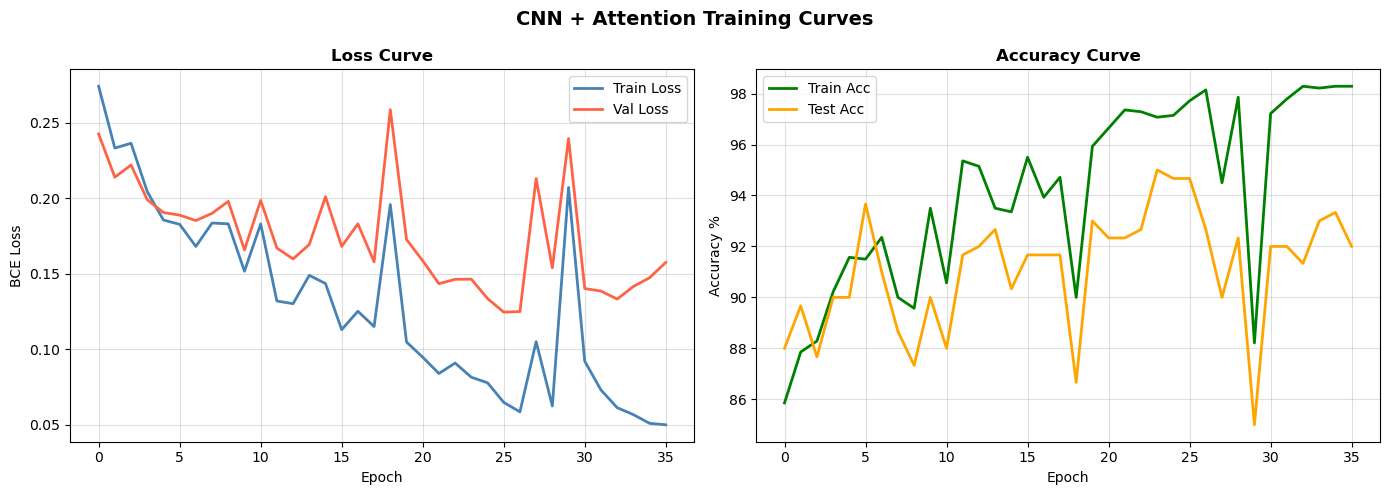

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(val_losses,   label='Val Loss',   color='tomato',    linewidth=2)
axes[0].set_title('Loss Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot([a*100 for a in train_accs], label='Train Acc', color='green',  linewidth=2)
axes[1].plot([a*100 for a in test_accs],  label='Test Acc',  color='orange', linewidth=2)
axes[1].set_title('Accuracy Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy %')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.suptitle('CNN + Attention Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 6 — Test Evaluation

In [11]:
y_prob = model.predict_proba(X_test)
y_pred = model.predict(X_test)
tr_acc = accuracy_score(y_train, model.predict(X_train))
acc  = accuracy_score(y_test,  y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test,    y_pred)
f1   = f1_score(y_test,        y_pred)
auc  = roc_auc_score(y_test,   y_prob)

print('CNN + ATTENTION RESULTS')
print('='*40)
print(f'Train Accuracy : {tr_acc*100:.2f}%')
print(f'Test  Accuracy : {acc*100:.2f}%')
print(f'Gap            : {(tr_acc-acc)*100:.2f}%')
print(f'Precision      : {prec*100:.2f}%')
print(f'Recall         : {rec*100:.2f}%')
print(f'F1-Score       : {f1*100:.2f}%')
print(f'ROC-AUC        : {auc:.4f}')
print('='*40)

CNN + ATTENTION RESULTS
Train Accuracy : 97.71%
Test  Accuracy : 94.67%
Gap            : 3.05%
Precision      : 95.12%
Recall         : 92.13%
F1-Score       : 93.60%
ROC-AUC        : 0.9872


In [12]:
print(classification_report(y_test, y_pred, target_names=['Normal', 'Blockage']))

              precision    recall  f1-score   support

      Normal       0.94      0.97      0.95       173
    Blockage       0.95      0.92      0.94       127

    accuracy                           0.95       300
   macro avg       0.95      0.94      0.95       300
weighted avg       0.95      0.95      0.95       300



---
## Step 7 — Confusion Matrix

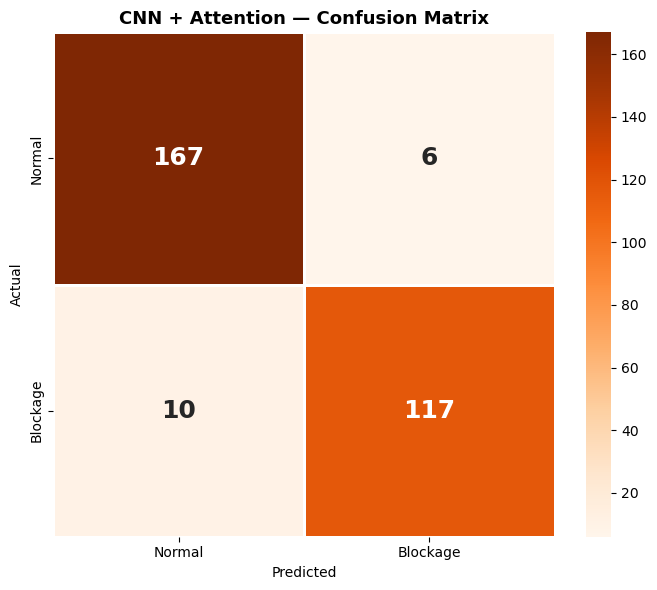

True  Normal   (TN): 167
False Alarm    (FP): 6
Missed Blockage(FN): 10
True  Blockage (TP): 117


In [13]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal','Blockage'],
            yticklabels=['Normal','Blockage'],
            linewidths=2, linecolor='white',
            annot_kws={'size':18,'weight':'bold'})
plt.title('CNN + Attention — Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f'True  Normal   (TN): {tn}')
print(f'False Alarm    (FP): {fp}')
print(f'Missed Blockage(FN): {fn}')
print(f'True  Blockage (TP): {tp}')

---
## Step 8 — ROC Curve

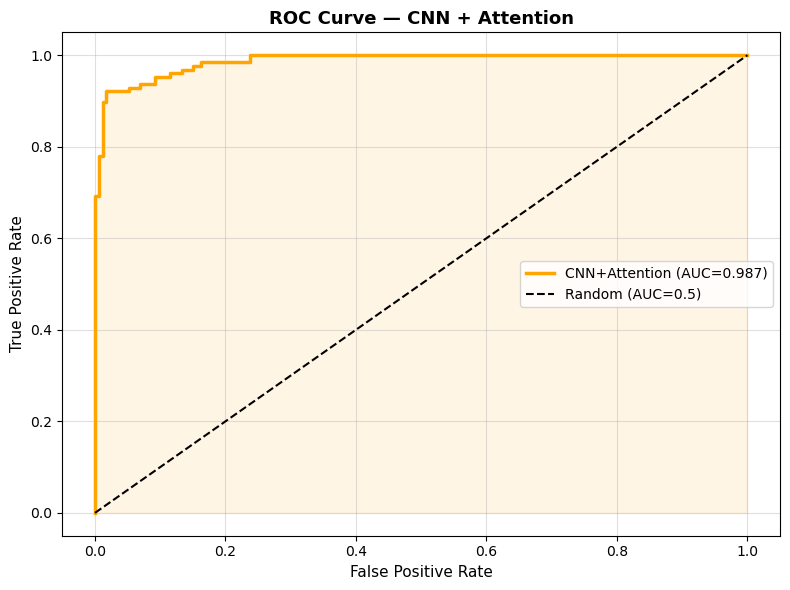

In [14]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', linewidth=2.5,
         label=f'CNN+Attention (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', linewidth=1.5, label='Random (AUC=0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='orange')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curve — CNN + Attention', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## Step 9 — Attention Weights Visualization

**Yeh sabse interesting part — model ne kaunsa feature zyada focus kiya?**

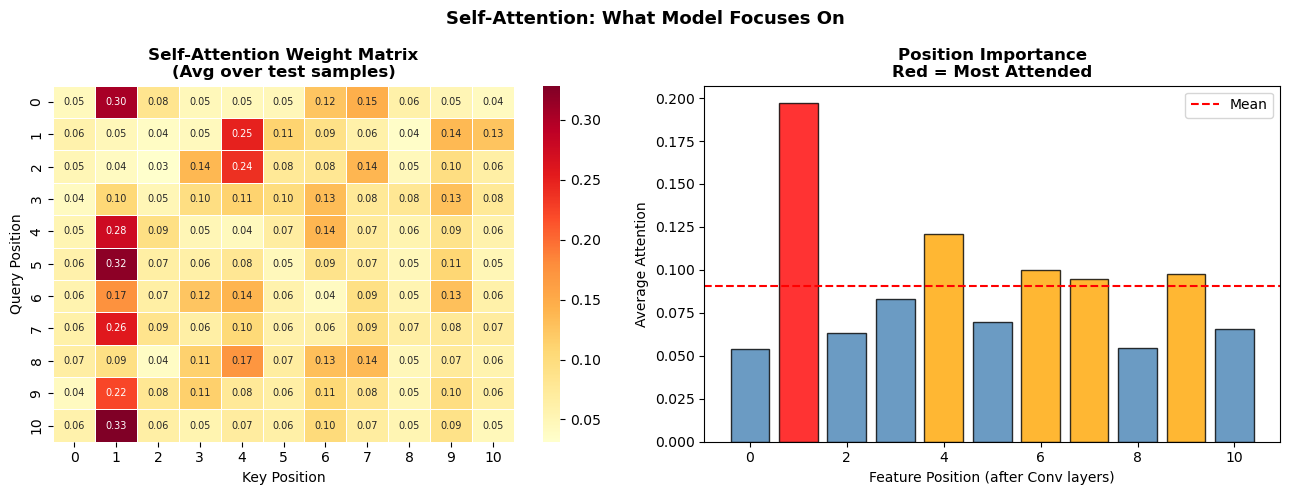

In [15]:
model.training = False
_ = model.forward(X_test[:50])
attn_weights = model.attn.A      # (50, 11, 11)
avg_attn = attn_weights.mean(axis=0)   # (11, 11)
pos_importance = avg_attn.mean(axis=0)  # (11,)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(avg_attn, cmap='YlOrRd', annot=True, fmt='.2f',
            annot_kws={'size':7}, linewidths=0.5, ax=axes[0])
axes[0].set_title('Self-Attention Weight Matrix\n(Avg over test samples)', fontweight='bold')
axes[0].set_xlabel('Key Position')
axes[0].set_ylabel('Query Position')

colors = ['red' if v > pos_importance.mean()+pos_importance.std()
          else 'orange' if v > pos_importance.mean()
          else 'steelblue' for v in pos_importance]
axes[1].bar(range(len(pos_importance)), pos_importance,
            color=colors, edgecolor='black', alpha=0.8)
axes[1].axhline(pos_importance.mean(), color='red', linestyle='--', label='Mean')
axes[1].set_title('Position Importance\nRed = Most Attended', fontweight='bold')
axes[1].set_xlabel('Feature Position (after Conv layers)')
axes[1].set_ylabel('Average Attention')
axes[1].legend()

plt.suptitle('Self-Attention: What Model Focuses On', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 10 — MLP vs CNN+Attention Comparison

In [16]:
try:
    with open('phase3_mlp_results.pkl','rb') as f:
        mlp_r = pickle.load(f)
    mlp_acc,mlp_f1,mlp_auc = mlp_r['accuracy'],mlp_r['f1'],mlp_r['auc']
except:
    mlp_acc,mlp_f1,mlp_auc = 0.9567, 0.9494, 0.9937

comp = pd.DataFrame({
    'Model'    : ['MLP','CNN + Attention'],
    'Accuracy%': [round(mlp_acc*100,2), round(acc*100,2)],
    'F1-Score%': [round(mlp_f1*100,2),  round(f1*100,2)],
    'ROC-AUC'  : [round(mlp_auc,4),     round(auc,4)],
})
print('Model Comparison:')
comp

Model Comparison:


,Model,Accuracy%,F1-Score%,ROC-AUC
0,MLP,95.67,94.94,0.9937
1,CNN + Attention,94.67,93.60,0.9872


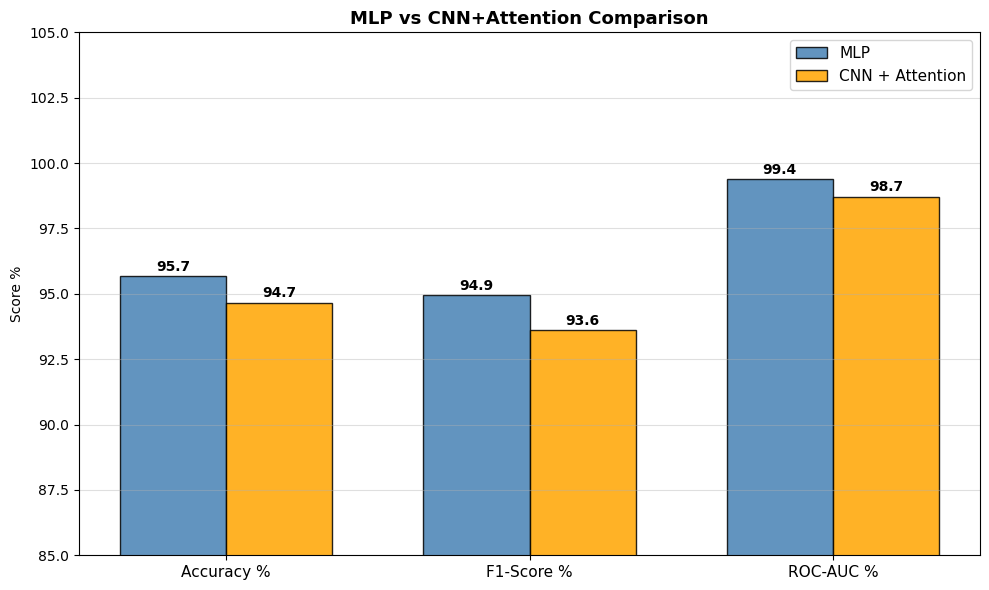

In [17]:
x = np.arange(3); width = 0.35
mlp_vals = [mlp_acc*100, mlp_f1*100, mlp_auc*100]
cnn_vals = [acc*100,     f1*100,     auc*100]

plt.figure(figsize=(10, 6))
b1=plt.bar(x-width/2, mlp_vals, width, label='MLP',             color='steelblue', edgecolor='black', alpha=0.85)
b2=plt.bar(x+width/2, cnn_vals, width, label='CNN + Attention', color='orange',    edgecolor='black', alpha=0.85)
for bar,val in zip(list(b1)+list(b2), mlp_vals+cnn_vals):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
plt.xticks(x, ['Accuracy %','F1-Score %','ROC-AUC %'], fontsize=11)
plt.ylim(85,105)
plt.ylabel('Score %')
plt.title('MLP vs CNN+Attention Comparison', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Step 11 — Save Model

In [18]:
with open('phase4_cnn_attn_model.pkl','wb') as f:
    pickle.dump(model, f)
with open('phase4_cnn_attn_scaler.pkl','wb') as f:
    pickle.dump(scaler, f)

cnn_results = {
    'name':'CNN+Attention','accuracy':acc,'precision':prec,
    'recall':rec,'f1':f1,'auc':auc,
    'y_prob_test':y_prob,'y_test':y_test
}
with open('phase4_cnn_results.pkl','wb') as f:
    pickle.dump(cnn_results, f)

print('Saved:')
print('  phase4_cnn_attn_model.pkl')
print('  phase4_cnn_attn_scaler.pkl')
print('  phase4_cnn_results.pkl  ← for Ensemble Phase 6')

Saved:
  phase4_cnn_attn_model.pkl
  phase4_cnn_attn_scaler.pkl
  phase4_cnn_results.pkl  ← for Ensemble Phase 6


---
## Phase 4 Summary

In [19]:
print('='*45)
print('  PHASE 4 — CNN + ATTENTION COMPLETE')
print('='*45)
print('Architecture : Input → Conv1D(32,k=3)')
print('             :       → Conv1D(64,k=3)')
print('             :       → SelfAttention(64)')
print('             :       → GlobalMaxPool')
print('             :       → Dense(64) → Dense(1)')
print('─'*45)
print(f'Train Acc    : {tr_acc*100:.2f}%')
print(f'Test  Acc    : {acc*100:.2f}%')
print(f'Gap          : {(tr_acc-acc)*100:.2f}%')
print(f'F1-Score     : {f1*100:.2f}%')
print(f'ROC-AUC      : {auc:.4f}')
print('='*45)
print('NEXT → PHASE 5: VAE (Variational Autoencoder)')
print('='*45)

  PHASE 4 — CNN + ATTENTION COMPLETE
Architecture : Input → Conv1D(32,k=3)
             :       → Conv1D(64,k=3)
             :       → SelfAttention(64)
             :       → GlobalMaxPool
             :       → Dense(64) → Dense(1)
─────────────────────────────────────────────
Train Acc    : 97.71%
Test  Acc    : 94.67%
Gap          : 3.05%
F1-Score     : 93.60%
ROC-AUC      : 0.9872
NEXT → PHASE 5: VAE (Variational Autoencoder)
